# SOC model Step 4: dynamic phonon workbench

This notebook keeps the same working structure as `SOC_steps_1_2_minimal_bright_dark_result_2_0.ipynb`, but uses the Step 4 temperature/field model. The active mixing term is

$$H_{mix}=V_{BD}^{static}L_{BD}+g_Q^{eff}QL_{BD}.$$

Edit `active_model_params` to choose your own parameter set, calculate rephasing or unrephasing spectra, and inspect real, imaginary, and absolute pathway-resolved panels.


In [32]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "SolverV8").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate PROJECT_ROOT containing SolverV8.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from SolverV8 import (
    LiouvilleSpectroscopySolver,
    SpectroscopyPlotter,
    standard_nq_protocol,
)


### Parameters

Edit `active_model_params` directly. The dictionary is initialized with one reasonable Step 4 parameter set, but no scan scenario is imposed by the notebook.

Useful calibration constants are still exposed:

- `matched_lambda_delta`: gives a static bright-dark contribution of about `0.01 eV` at the low-temperature reference dimerisation.
- `matched_lambda_C_highT`: gives a static bright-dark contribution of about `0.01 eV` from the high-temperature `C1` reference.


In [ ]:
def spin_peierls_transition_temperature(B, T_SP_0, alpha_field):
    return max(0.0, float(T_SP_0) * (1.0 - float(alpha_field) * float(B) ** 2))


def spin_peierls_delta(T, B, T_SP_0, delta_0, beta, alpha_field):
    T_SP = spin_peierls_transition_temperature(B, T_SP_0, alpha_field)
    if T_SP > 0.0 and T < T_SP:
        return float(delta_0) * (1.0 - float(T) / T_SP) ** float(beta)
    return 0.0


def spin_correlation_proxy(T, B, T_SP_0, C1_lowT, C1_highT, C1_field_scale):
    thermal_weight = 1.0 / (1.0 + float(T) / float(T_SP_0))
    field_weight = 1.0 / (1.0 + float(C1_field_scale) * float(B) ** 2)
    return float(C1_highT) + (float(C1_lowT) - float(C1_highT)) * thermal_weight * field_weight


trend_params = {
    "T_SP_0": 14.0,
    "delta_0": 0.01,
    "beta": 0.5,
    "alpha_field": 0.004,
    "T_ref": 7.0,
    "B_ref": 0.0,
    "C1_lowT": -0.443,
    "C1_highT": -0.25,
    "C1_field_scale": 0.0015,
}

delta_ref = spin_peierls_delta(
    trend_params["T_ref"],
    trend_params["B_ref"],
    trend_params["T_SP_0"],
    trend_params["delta_0"],
    trend_params["beta"],
    trend_params["alpha_field"],
)
C1_highT_ref = spin_correlation_proxy(
    20.0,
    0.0,
    trend_params["T_SP_0"],
    trend_params["C1_lowT"],
    trend_params["C1_highT"],
    trend_params["C1_field_scale"],
)
matched_lambda_delta = 0.01 / delta_ref
matched_lambda_C_highT = 0.01 / C1_highT_ref

base_model_params = {
    # Orbital sector: |g>, |D>, |B>
    "Delta_dark": 0.90,
    "Delta_Bright": 1.00,
    "mu_B": 1.0,
    "mu_D": 0.0,

    # Static bright-dark mixing controls
    "V0": 0.01,
    "lambda_delta": 0.0,
    "lambda_C": 0.0,

    # Dynamic phonon channel
    "n_bosons": 3,
    "omega_Q": 0.035,
    "g_Q0": 0.010,
    "g_Q_source": "off",
    "g_Q_external": 0.0,

    # Temperature/field trend controls
    **trend_params,
    "T": 7.0,
    "B": 0.0,
    "N_k": 1,

    # Dissipation, kept explicit for coherent controls
    "gamma_orb": 0.0,
    "gamma_phonon": 0.0,
}


active_model_params = {
    **base_model_params,
    "label": "custom_step4",

    # Edit these values for the parameter set you want to inspect.
    "T": 7.0,
    "B": 0.0,
    "lambda_delta": matched_lambda_delta,
    "lambda_C": 0.0,
    "g_Q_source": "delta_scaled",
}

solver_params = {
    "T": 0.0,
    "Eta": 0.005,
    "backend": "dense",
    "parallel_backend": "threading",
    "n_jobs": -1,
}

print("Edit active_model_params, then run the solver setup cell.")


Edit active_model_params, then run the solver setup cell.


### Model Builder


In [34]:
def resolve_trends(params):
    T_SP = spin_peierls_transition_temperature(params["B"], params["T_SP_0"], params["alpha_field"])
    delta = spin_peierls_delta(
        params["T"], params["B"], params["T_SP_0"], params["delta_0"], params["beta"], params["alpha_field"]
    )
    C1 = spin_correlation_proxy(
        params["T"], params["B"], params["T_SP_0"], params["C1_lowT"], params["C1_highT"], params["C1_field_scale"]
    )
    return T_SP, delta, C1


def resolve_g_Q(params, delta):
    if params["g_Q_source"] == "delta_scaled":
        return float(params["g_Q0"]) * float(delta) / max(float(delta_ref), 1e-15)
    if params["g_Q_source"] == "external":
        return float(params["g_Q_external"])
    return 0.0


def static_bright_dark_mixing(params, delta, C1):
    return float(params["V0"]) + float(params["lambda_delta"]) * float(delta) + float(params["lambda_C"]) * float(C1)


def lowering_operator(n):
    op = np.zeros((n, n), dtype=complex)
    for upper in range(1, n):
        op[upper - 1, upper] = np.sqrt(upper)
    return op


def build_temperature_field_model(params):
    N_k = int(params["N_k"])
    if N_k != 1:
        raise NotImplementedError("Step 4 keeps N_k=1 to isolate trend controls.")
    k_array = np.array([0.0])
    k_weights = np.ones(1)

    n_bosons = int(params["n_bosons"])
    ket_g, ket_d, ket_b = 0, 1, 2

    H_orb = np.zeros((3, 3), dtype=complex)
    H_orb[ket_d, ket_d] = params["Delta_dark"]
    H_orb[ket_b, ket_b] = params["Delta_Bright"]

    L_bd = np.zeros((3, 3), dtype=complex)
    L_bd[ket_d, ket_b] = 1.0
    L_bd[ket_b, ket_d] = 1.0

    mu_orb = np.zeros((3, 3), dtype=complex)
    mu_orb[ket_g, ket_b] = params["mu_B"]
    mu_orb[ket_b, ket_g] = params["mu_B"]
    mu_orb[ket_g, ket_d] = params["mu_D"]
    mu_orb[ket_d, ket_g] = params["mu_D"]

    a = lowering_operator(n_bosons)
    adag = a.conj().T
    n_op = adag @ a
    q_op = a + adag

    I_orb = np.eye(3, dtype=complex)
    I_ph = np.eye(n_bosons, dtype=complex)
    dim = 3 * n_bosons

    T_SP, delta, C1 = resolve_trends(params)
    V_BD_static = static_bright_dark_mixing(params, delta, C1)
    g_Q_eff = resolve_g_Q(params, delta)

    H_local = np.kron(H_orb, I_ph)
    H_phonon = float(params["omega_Q"]) * np.kron(I_orb, n_op)
    H_static_mix = V_BD_static * np.kron(L_bd, I_ph)
    H_dynamic_mix = g_Q_eff * np.kron(L_bd, q_op)

    H = H_local + H_phonon + H_static_mix + H_dynamic_mix
    mu = np.kron(mu_orb, I_ph)
    rho0 = np.zeros((dim, dim), dtype=complex)
    rho0[0, 0] = 1.0

    c_ops = []
    if params["gamma_phonon"]:
        c_ops.append((np.kron(I_orb, a)[None, :, :], params["gamma_phonon"]))
    if params["gamma_orb"]:
        C_bg = np.zeros((3, 3), dtype=complex)
        C_bg[ket_g, ket_b] = 1.0
        C_dg = np.zeros((3, 3), dtype=complex)
        C_dg[ket_g, ket_d] = 1.0
        c_ops.append((np.kron(C_bg, I_ph)[None, :, :], params["gamma_orb"]))
        c_ops.append((np.kron(C_dg, I_ph)[None, :, :], params["gamma_orb"]))

    metadata = {
        "k_array": k_array,
        "k_weights": k_weights,
        "T_SP": float(T_SP),
        "delta": float(delta),
        "C1": float(C1),
        "delta_ref": float(delta_ref),
        "C1_highT_ref": float(C1_highT_ref),
        "V_BD_static": float(V_BD_static),
        "omega_Q": float(params["omega_Q"]),
        "g_Q_eff": float(g_Q_eff),
        "dim": dim,
    }
    return H[None, :, :], mu[None, :, :], c_ops, rho0[None, :, :], metadata


### Solver Setup


In [35]:
def resolve_model_params(params=None):
    if params is None:
        params = active_model_params
    merged = {**base_model_params, **params}
    merged.setdefault("label", "custom_step4")
    return merged


def make_solver(params):
    H, mu, c_ops, rho0, meta = build_temperature_field_model(params)
    solver = LiouvilleSpectroscopySolver(solver_params)
    solver.feed_model(
        H,
        mu,
        c_ops_raw=c_ops,
        initial_density_matrix=rho0,
        density_matrix_basis="site",
    )
    return solver, meta


active_params = resolve_model_params(active_model_params)
solver, meta = make_solver(active_params)
print(active_params["label"])
print("Hilbert dimension:", meta["dim"])
print("N_k:", len(meta["k_array"]))
print("T_SP:", meta["T_SP"])
print("delta:", meta["delta"])
print("C1:", meta["C1"])
print("V_BD_static:", meta["V_BD_static"])
print("g_Q_eff:", meta["g_Q_eff"])
print("Hamiltonien dimensions:", solver.H_eigen.shape)


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
custom_step4
Hilbert dimension: 9
N_k: 1
T_SP: 14.0
delta: 0.007071067811865476
C1: -0.37866666666666665
V_BD_static: 0.02
g_Q_eff: 0.01
Hamiltonien dimensions: (1, 9, 9)


### Third-Order 1Q Pathways With NQ Protocol


In [36]:
def configure_2d_protocol(solver):
    arrival_times = [0.0, 100.0, 200.0]
    pathways = solver.configure_standard_2d_pathways_with_ufss(arrival_times)
    protocol = standard_nq_protocol(
        order=1,
        nq_interval=1,
        detection_interval=3,
        n_interactions=3,
        nq_axis="omega1",
        detection_axis="omega3",
    )
    return arrival_times, pathways, protocol


arrival_times, pathways, protocol = configure_2d_protocol(solver)
rephasing_pathways = solver.get_pathways("rephasing")
unrephasing_pathways = solver.get_pathways("unrephasing")

[(p.name, p.component, p.interactions, p.coherence_orders) for p in pathways]


[('R1', 'rephasing', ('Bu', 'Ku', 'Bd'), (-1, 0, 1)),
 ('R2', 'rephasing', ('Bu', 'Bd', 'Ku'), (-1, 0, 1)),
 ('R3', 'rephasing', ('Bu', 'Ku', 'Ku'), (-1, 0, 1)),
 ('R4', 'unrephasing', ('Ku', 'Bu', 'Ku'), (1, 0, 1)),
 ('R5', 'unrephasing', ('Ku', 'Bu', 'Bd'), (1, 0, 1)),
 ('R6', 'unrephasing', ('Ku', 'Kd', 'Ku'), (1, 0, 1))]

### Spectrum Axes

The quadrant convention is explicit:

- rephasing: `omega1 < 0`, `omega3 > 0`
- unrephasing: `omega1 > 0`, `omega3 > 0`

Edit `N_w` or the window bounds here before running a spectrum.


In [37]:
N_w = 100
omega1_rephasing = np.linspace(-1.1, -0.8, N_w)
omega1_unrephasing = np.linspace(0.8, 1.1, N_w)
omega3 = np.linspace(0.8, 1.1, N_w)
tau2 = 3.0
DETECTION_PHASE = np.pi / 2

print("rephasing omega1:", omega1_rephasing[0], omega1_rephasing[-1])
print("unrephasing omega1:", omega1_unrephasing[0], omega1_unrephasing[-1])
print("omega3:", omega3[0], omega3[-1])


rephasing omega1: -1.1 -0.8
unrephasing omega1: 0.8 1.1
omega3: 0.8 1.1


### Spectrum Calculation For A Chosen Parameter Set

Use `calculate_selected_spectra(params)` to calculate both components for one parameter dictionary. Use `calculate_component_spectrum(params, "rephasing")` or `calculate_component_spectrum(params, "unrephasing")` when you only need one component.

If `params=None`, the functions use `active_model_params`.


In [38]:
def calculate_component_spectrum(params=None, component="rephasing", verbose=True):
    params = resolve_model_params(params)
    local_solver, meta = make_solver(params)
    arrival_times, pathways, protocol = configure_2d_protocol(local_solver)
    component_pathways = [pathway for pathway in pathways if pathway.component == component]
    if component == "rephasing":
        omega1_axis = omega1_rephasing
    elif component == "unrephasing":
        omega1_axis = omega1_unrephasing
    else:
        raise ValueError("component must be 'rephasing' or 'unrephasing'.")

    result = local_solver.generate_NQ_spectrum(
        1,
        protocol,
        axes={"omega1": omega1_axis, "omega3": omega3},
        delays={"t2": tau2},
        pathways=component_pathways,
        k_array=meta["k_array"],
        k_weights=meta["k_weights"],
        verbose=verbose,
    )
    return {
        "result": result,
        "solver": local_solver,
        "params": params,
        "label": params.get("label", "custom_step4"),
        "meta": meta,
        "pathways": component_pathways,
    }


def calculate_selected_spectra(params=None, components=("rephasing", "unrephasing"), verbose=True):
    output = {}
    for component in components:
        output[component] = calculate_component_spectrum(params, component=component, verbose=verbose)
    return output


# Example, intentionally commented so the notebook does not launch a calculation on load.
# selected = calculate_selected_spectra(active_model_params, verbose=True)


### Pathway Plotter

`Step4PathwayPlotter.print_pathway_views(...)` displays real, imaginary, and absolute views for each selected pathway and the requested total. It uses the solver's `SpectrumResult` directly, so it works for either rephasing or unrephasing results.


In [39]:
class Step4PathwayPlotter(SpectroscopyPlotter):
    def print_pathway_views(
        self,
        spectrum_result,
        views=("real", "imag", "abs"),
        pathways="all",
        totals="auto",
        normalization="shared",
        include_diagrams=False,
        ncols=None,
        show=True,
    ):
        figures = {}
        axis_labels = {
            "omega1": "1Q frequency (eV)",
            "omega3": "Detection frequency (eV)",
        }
        for view in views:
            print(f"{view.upper()} pathway panels")
            figures[view] = self.plot_pathways_multiorder(
                spectrum_result,
                pathways=pathways,
                totals=totals,
                view=view,
                normalization=normalization,
                ncols=ncols,
                axis_labels=axis_labels,
                include_diagrams=include_diagrams,
                show=show,
            )
        return figures


def plot_selected_parameter_set(
    params=None,
    component="rephasing",
    views=("real", "imag", "abs"),
    pathways="all",
    totals="auto",
    normalization="shared",
    verbose=True,
):
    calculation = calculate_component_spectrum(params, component=component, verbose=verbose)
    print("label:", calculation["label"])
    print("component:", component)
    print("delta:", calculation["meta"]["delta"])
    print("C1:", calculation["meta"]["C1"])
    print("V_BD_static:", calculation["meta"]["V_BD_static"])
    print("g_Q_eff:", calculation["meta"]["g_Q_eff"])
    plotter = Step4PathwayPlotter(detection_phase=DETECTION_PHASE)
    figures = plotter.print_pathway_views(
        calculation["result"],
        views=views,
        pathways=pathways,
        totals=totals,
        normalization=normalization,
    )
    return calculation, figures


### Launch Cells

Edit `active_model_params`, then run one of the examples below. Rephasing and unrephasing use different `omega1` quadrants.


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Calculating 3 pathway spectrum/s on a 100x100 grid with protocol 'standard_1q'.
Using dense prefix-tree pathway reuse.
label: custom_step4
component: rephasing
delta: 0.007071067811865476
C1: -0.37866666666666665
V_BD_static: 0.02
g_Q_eff: 0.01
REAL pathway panels


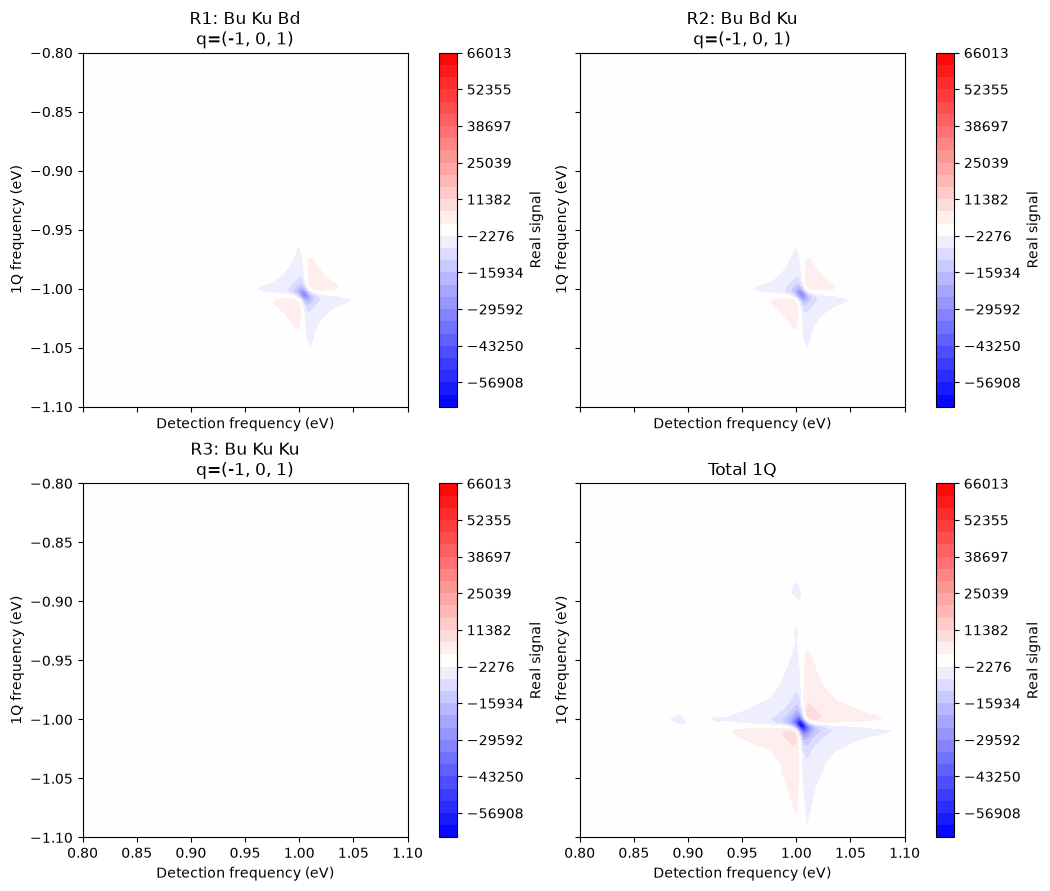

IMAG pathway panels


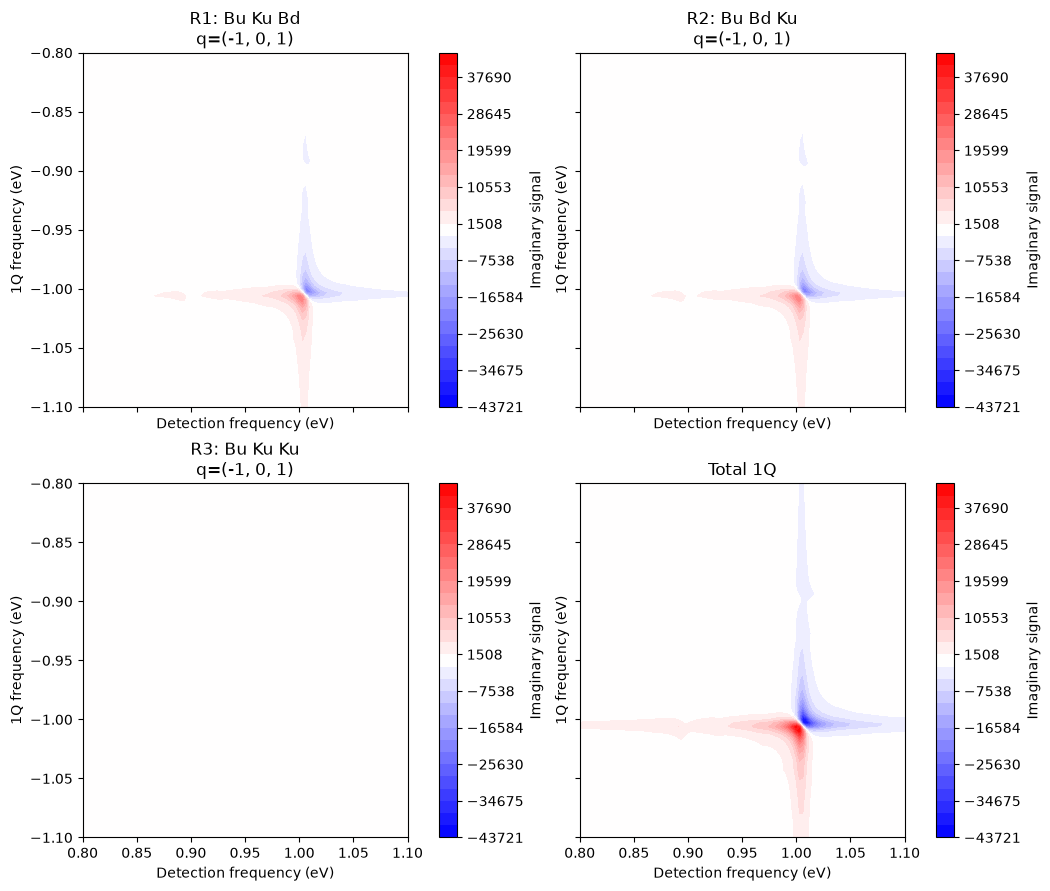

ABS pathway panels


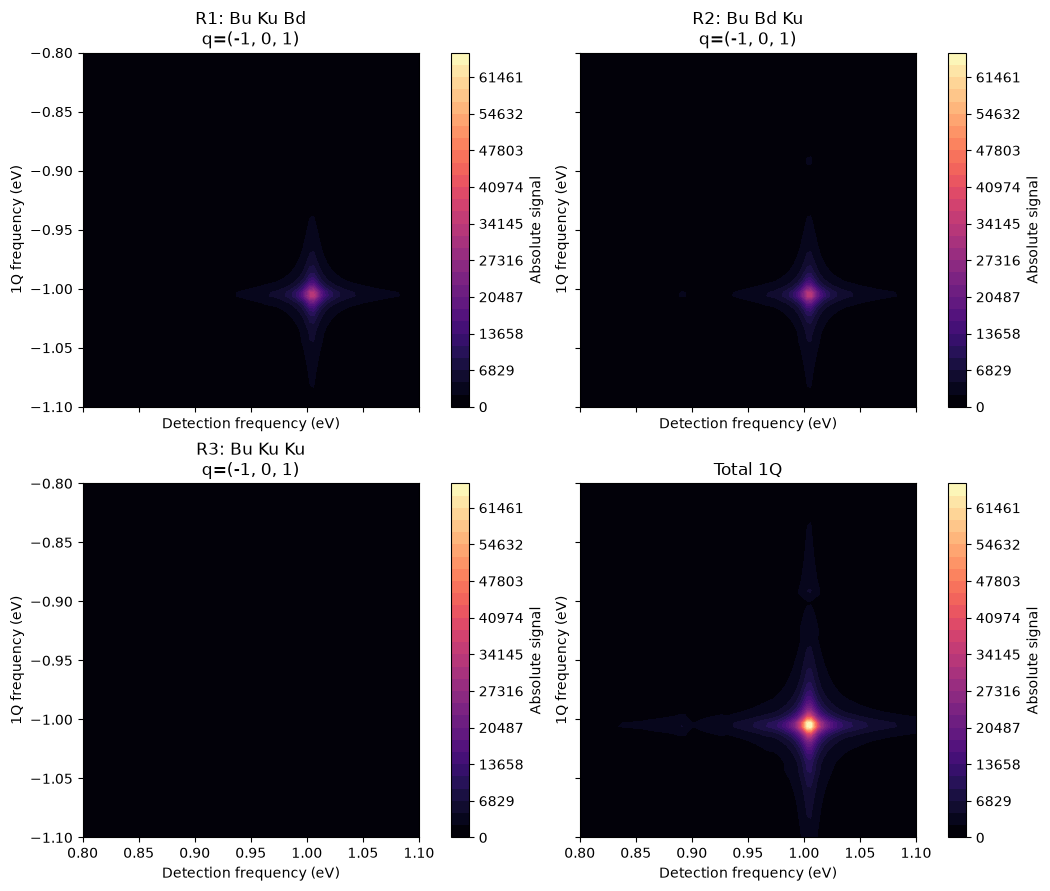

In [40]:
# Example: plot real, imaginary, and absolute panels for all rephasing pathways.
calculation, figures = plot_selected_parameter_set(
    params=active_model_params,
    component="rephasing",
    views=("real", "imag", "abs"),
    pathways="all",
    totals="auto",
    normalization="none",
    verbose=True,
    )

# Example: plot unrephasing pathways in the positive omega1 quadrant.
# calculation, figures = plot_selected_parameter_set(params=active_model_params, component="unrephasing")

# Example: try a modified parameter set without changing active_model_params.
# trial_params = {
#     **active_model_params,
#     "label": "trial_high_field",
#     "B": 12.0,
# }
# calculation, figures = plot_selected_parameter_set(params=trial_params, component="rephasing")

# Example: only plot selected pathway names and the selected total.
# calculation, figures = plot_selected_parameter_set(
#     params=active_model_params,
#     component="rephasing",
#     pathways=["R1", "R2"],
#     totals="selected",
# )


### Lightweight Parameter-Set Loop

This loop is for interactive exploration over your own list of parameter dictionaries. It does not save production result files.


--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Calculating 3 pathway spectrum/s on a 100x100 grid with protocol 'standard_1q'.
Using dense prefix-tree pathway reuse.
label: case_A
component: rephasing
delta: 0.007071067811865476
C1: -0.37866666666666665
V_BD_static: 0.02
g_Q_eff: 0.01
REAL pathway panels


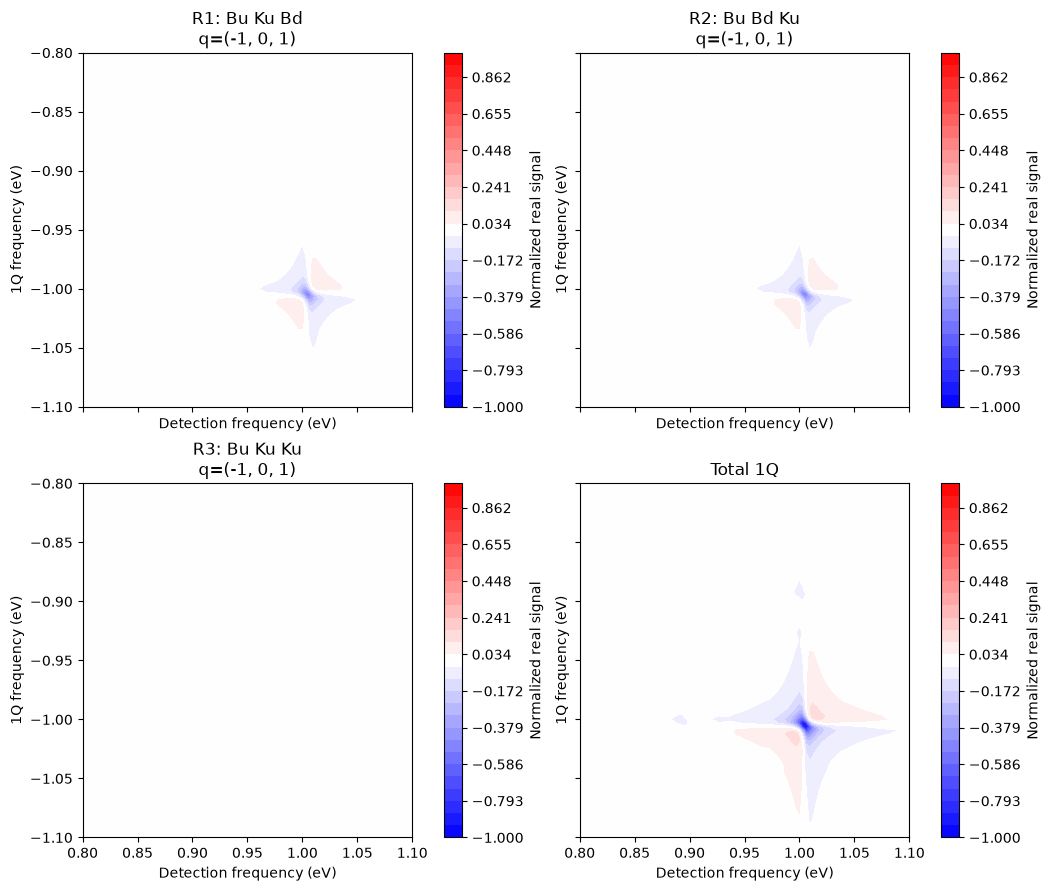

IMAG pathway panels


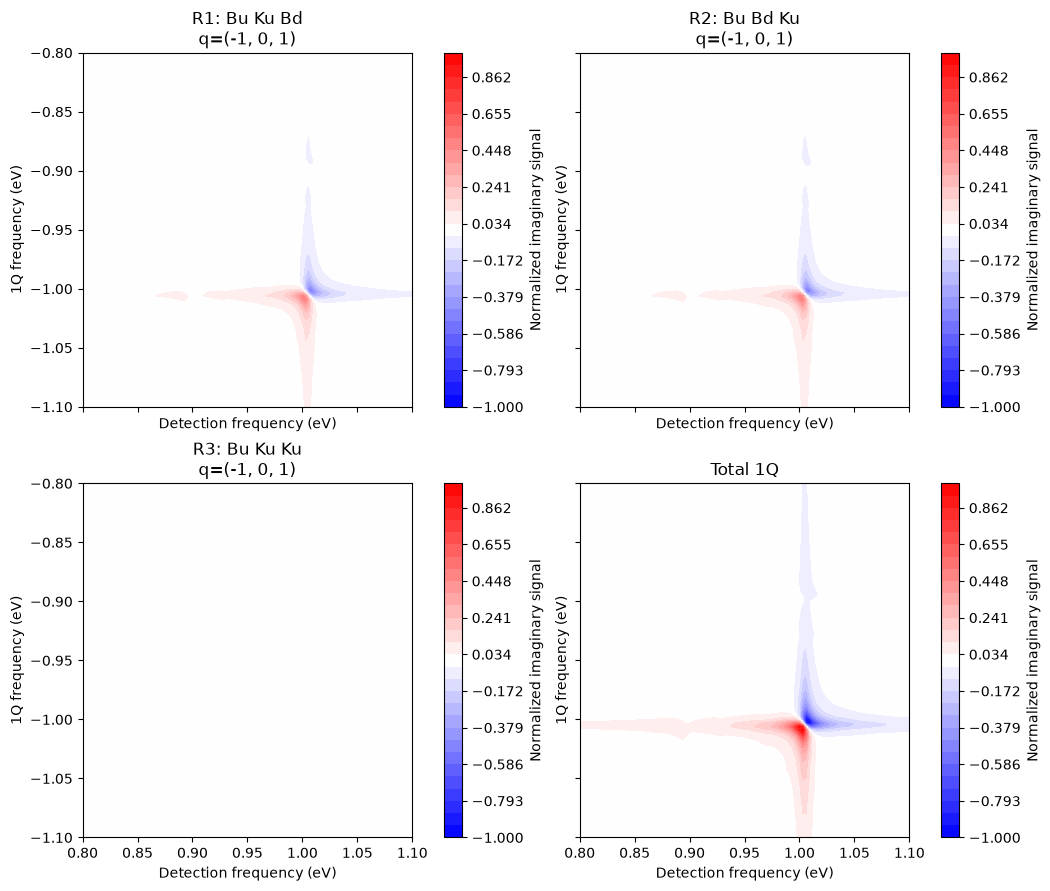

ABS pathway panels


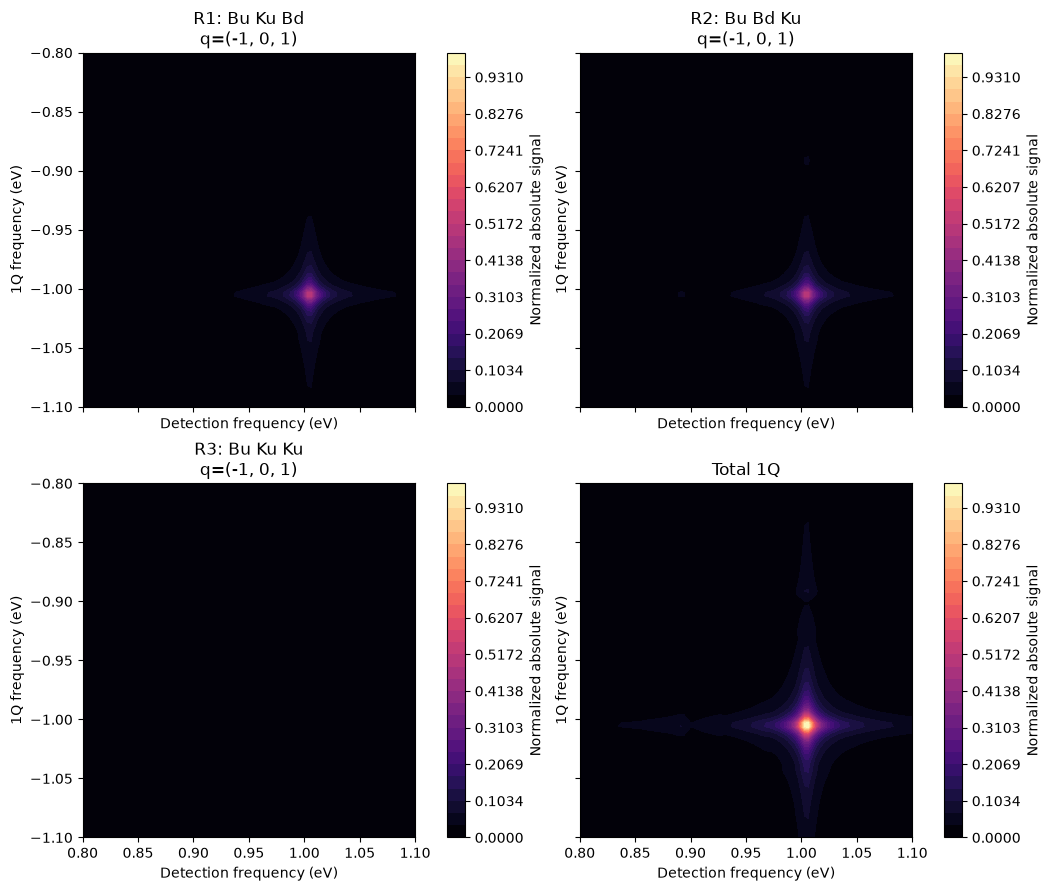

NotImplementedError: Step 4 keeps N_k=1 to isolate trend controls.

In [42]:
def loop(parameter_sets, component="rephasing", plot=True, views=("real", "imag", "abs"), verbose=True):
    outputs = []
    for params in parameter_sets:
        params = resolve_model_params(params)
        if plot:
            calculation, figures = plot_selected_parameter_set(
                params=params,
                component=component,
                views=views,
                verbose=verbose,
            )
            outputs.append({"calculation": calculation, "figures": figures})
        else:
            outputs.append(calculate_component_spectrum(params, component=component, verbose=verbose))
    return outputs


# Example:
my_parameter_sets = [
    {**active_model_params, "label": "case_A", "T": 7.0, "B": 0.0, 'N_k' : 1 },
    {**active_model_params, "label": "case_B", "T": 20.0, "B": 0.0, 'N_k': 50},
]
outputs = loop(my_parameter_sets, component="rephasing", plot=True)
